# 05. Animations

A time series of maps is easiest to read as an animation. This notebook turns the cubes saved by notebooks 02, 03 and 04 into animated GIFs (embedded below) and MP4 videos (written next to them):

1. three weeks of daytime land surface temperature over Berlin;
2. the observed 1 km scene next to its 100 m downscaled version, scene by scene;
3. a Sentinel-2 true-colour and NDVI time-lapse;
4. a map and its city-wide time series moving together;
5. Sentinel-5P nitrogen dioxide.

Run notebooks 02, 03 and 04 first: this one only reads their results from `output/notebooks/`.

Animations are built with matplotlib's `FuncAnimation`: draw the first frame once, then update only the image data and the title for every frame. `PillowWriter` writes GIFs and `FFMpegWriter` writes MP4 (it needs `ffmpeg` installed).

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dotenv import dotenv_values, load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "output" / "notebooks"
WORK = OUT / "work"  # shared download/subset cache: later notebooks reuse it
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Credentials live in the repository's .env (see docs/setup.md). The
# Earthdata token is often kept only in worker/.env; fall back to it.
load_dotenv(ROOT / ".env")
if not os.getenv("EARTHDATA_BEARER_TOKEN"):
    token = dotenv_values(ROOT / "worker" / ".env").get("EARTHDATA_BEARER_TOKEN")
    if token:
        os.environ["EARTHDATA_BEARER_TOKEN"] = token

# Upstream notices (numpy/xarray/matplotlib internals, all-NaN slices of
# cloudy scenes) that say nothing about the analysis.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "image.origin": "upper"})
pd.set_option("display.max_colwidth", 70)

In [2]:
def extent_km(da):
    """imshow extent of a projected y/x grid, in kilometres."""
    x, y = da["x"].values, da["y"].values
    dx, dy = abs(x[1] - x[0]), abs(y[1] - y[0])
    return [(x.min() - dx / 2) / 1e3, (x.max() + dx / 2) / 1e3, (y.min() - dy / 2) / 1e3, (y.max() + dy / 2) / 1e3]


def show_map(ax, da, title, cmap="inferno", label=None, vmin=None, vmax=None):
    """One georeferenced map with a colour bar; axes in UTM kilometres."""
    image = ax.imshow(da.values, extent=extent_km(da), cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("easting (km)")
    ax.set_ylabel("northing (km)")
    plt.colorbar(image, ax=ax, shrink=0.8, label=label or da.attrs.get("units", ""))
    return image

In [3]:
from IPython.display import Image, display
from matplotlib import animation

import citycube as cc

ANIMATIONS = OUT / "animations"
ANIMATIONS.mkdir(parents=True, exist_ok=True)
thermal = cc.open_zarr(OUT / "02_export" / "result" / "thermal_cube.zarr").load()
fusion = cc.open_zarr(OUT / "03_export" / "result" / "cube.zarr").load()
sentinel2 = cc.open_zarr(OUT / "03_export" / "result" / "predictors" / "sentinel2.zarr").load()
sentinel5p = cc.open_zarr(OUT / "03_export" / "result" / "predictors" / "sentinel5p.zarr").load()
downscaled = cc.open_zarr(OUT / "04_export" / "result" / "downscaled.zarr").load()
coarse = cc.open_zarr(OUT / "04_export" / "result" / "cube.zarr").load()


def save_animation(anim, name, fps=2):
    """Write a GIF (shown inline) and an MP4 of the same animation."""
    gif = ANIMATIONS / f"{name}.gif"
    anim.save(gif, writer=animation.PillowWriter(fps=fps), dpi=80)
    if animation.FFMpegWriter.isAvailable():
        anim.save(ANIMATIONS / f"{name}.mp4", writer=animation.FFMpegWriter(fps=fps, bitrate=1800), dpi=110)
    plt.close(anim._fig)
    print(f"{gif.name}: {gif.stat().st_size / 1e6:.1f} MB")
    display(Image(filename=str(gif)))

## 1. Three weeks of land surface temperature

Only scenes with at least 30 % of the city clear are used, on one fixed colour scale so frames are comparable. Grey cells are clouds or failed quality checks.

lst_berlin.gif: 0.4 MB


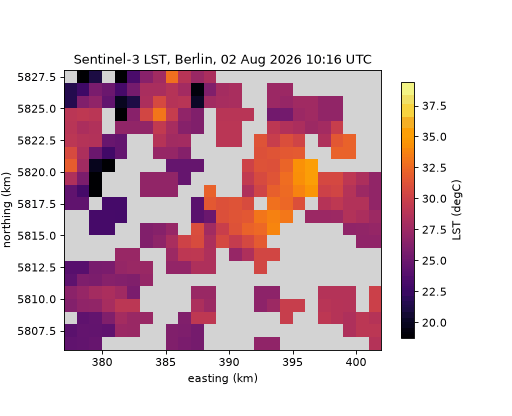

In [4]:
valid = thermal["lst"].notnull().mean(["y", "x"])
frames = thermal["lst"].isel(time=np.flatnonzero(valid.values >= 0.3))
lst_low, lst_high = np.nanpercentile(frames.values, [2, 98])
cmap = plt.get_cmap("inferno").copy()
cmap.set_bad("lightgrey")

fig, ax = plt.subplots(figsize=(6.4, 5.2))
image = show_map(ax, frames.isel(time=0), "", cmap=cmap, label="LST (degC)", vmin=lst_low, vmax=lst_high)


def update(index):
    layer = frames.isel(time=index)
    image.set_data(layer.values)
    ax.set_title(f"Sentinel-3 LST, Berlin, {pd.Timestamp(layer.time.values):%d %b %Y %H:%M} UTC")
    return (image,)


save_animation(animation.FuncAnimation(fig, update, frames=frames.sizes["time"]), "lst_berlin")

## 2. Observed and downscaled, side by side

Left: the 1 km Sentinel-3 observation. Right: the same scene sharpened to 100 m by notebook 04's per-scene Random Forest; averaged back to 1 km it reproduces the left panel.

observed_vs_downscaled.gif: 1.4 MB


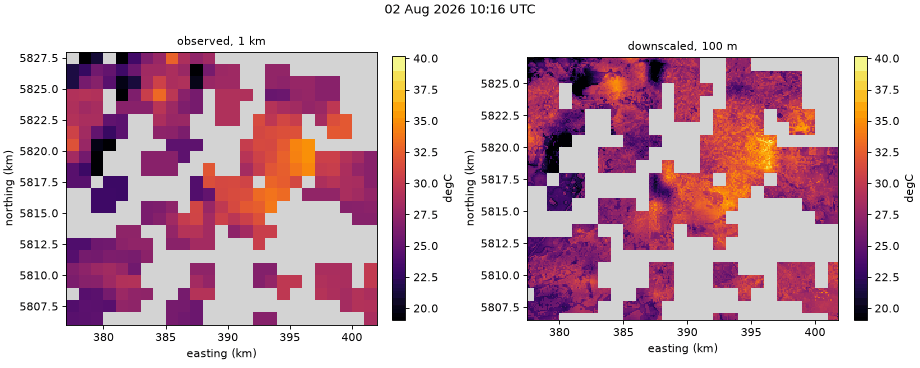

In [5]:
ds_low, ds_high = np.nanpercentile(downscaled["lst_downscaled"].values, [2, 98])
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
left = show_map(axes[0], coarse["lst"].sel(time=downscaled.time.values[0]), "observed, 1 km", cmap=cmap, label="degC", vmin=ds_low, vmax=ds_high)
right = show_map(axes[1], downscaled["lst_downscaled"].isel(time=0), "downscaled, 100 m", cmap=cmap, label="degC", vmin=ds_low, vmax=ds_high)
title = fig.suptitle("")


def update(index):
    when = downscaled.time.values[index]
    left.set_data(coarse["lst"].sel(time=when).values)
    right.set_data(downscaled["lst_downscaled"].isel(time=index).values)
    title.set_text(f"{pd.Timestamp(when):%d %b %Y %H:%M} UTC")
    return left, right


save_animation(animation.FuncAnimation(fig, update, frames=downscaled.sizes["time"]), "observed_vs_downscaled", fps=1)

## 3. Sentinel-2 time-lapse

True colour from bands B04, B03 and B02 next to NDVI. Only the dates where most of Berlin was cloud-free (per Sentinel-2's own scene classification) are kept.

sentinel2_timelapse.gif: 0.8 MB


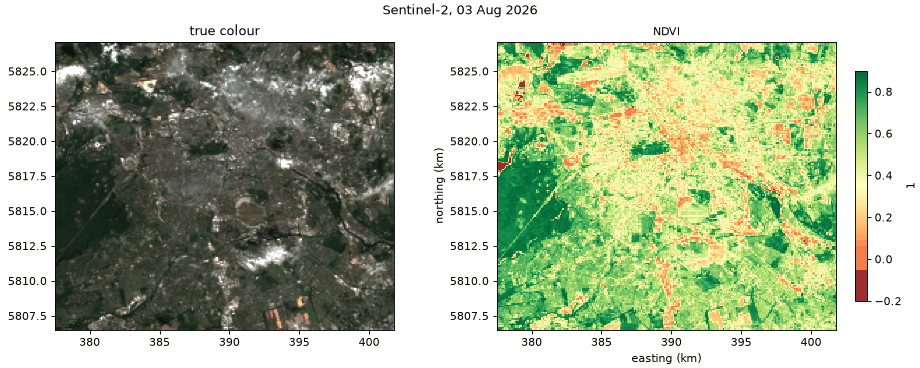

In [6]:
clear_s2 = sentinel2["NDVI"].notnull().mean(["y", "x"])
s2 = sentinel2.isel(time=np.flatnonzero(clear_s2.values >= 0.6))


def true_colour(scene):
    stack = np.dstack([scene[band].values for band in ("B04", "B03", "B02")])
    return np.clip(stack / 0.25, 0, 1)  # reflectance 0.25 shown as full brightness


fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
first = s2.isel(time=0)
rgb = axes[0].imshow(true_colour(first), extent=extent_km(first["NDVI"]))
axes[0].set_title("true colour")
ndvi = show_map(axes[1], first["NDVI"], "NDVI", cmap="RdYlGn", label="", vmin=-0.2, vmax=0.9)
title = fig.suptitle("")


def update(index):
    scene = s2.isel(time=index)
    rgb.set_data(true_colour(scene))
    ndvi.set_data(scene["NDVI"].values)
    title.set_text(f"Sentinel-2, {pd.Timestamp(scene.time.values):%d %b %Y}")
    return rgb, ndvi


save_animation(animation.FuncAnimation(fig, update, frames=s2.sizes["time"]), "sentinel2_timelapse", fps=1)

## 4. A map and its time series together

The left panel steps through the scenes while the right panel draws the city-wide median up to the current date, which links each map to where it sits in the series.

map_and_series.gif: 0.5 MB


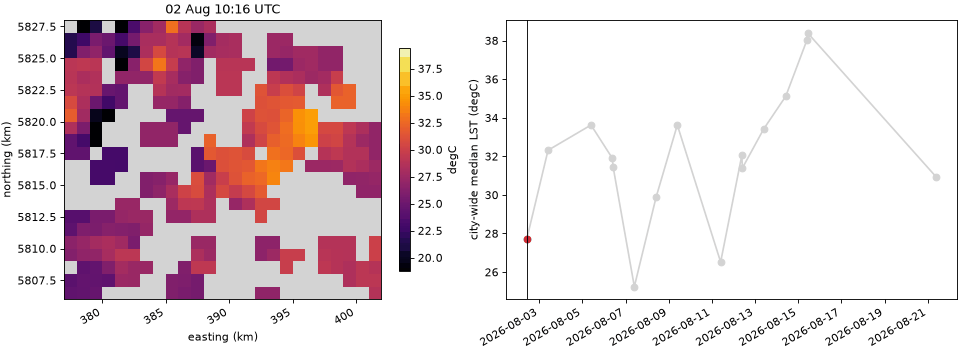

In [7]:
median = frames.median(["y", "x"]).to_series()

fig, (map_ax, line_ax) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1, 1.3]}, constrained_layout=True)
image = show_map(map_ax, frames.isel(time=0), "", cmap=cmap, label="degC", vmin=lst_low, vmax=lst_high)
line_ax.plot(median.index, median.values, color="lightgrey", marker="o")
(trace,) = line_ax.plot([], [], color="tab:red", marker="o")
marker = line_ax.axvline(median.index[0], color="black", lw=0.8)
line_ax.set_ylabel("city-wide median LST (degC)")
fig.autofmt_xdate()


def update(index):
    image.set_data(frames.isel(time=index).values)
    map_ax.set_title(f"{median.index[index]:%d %b %H:%M} UTC")
    trace.set_data(median.index[: index + 1], median.values[: index + 1])
    marker.set_xdata([median.index[index]] * 2)
    return image, trace, marker


save_animation(animation.FuncAnimation(fig, update, frames=len(median)), "map_and_series")

## 5. Nitrogen dioxide from Sentinel-5P

TROPOMI's tropospheric NO2 column, regridded from its native 0.01 degree grid onto the 100 m predictor grid. Plumes from the city and its motorways change daily with the wind.

no2_berlin.gif: 0.1 MB


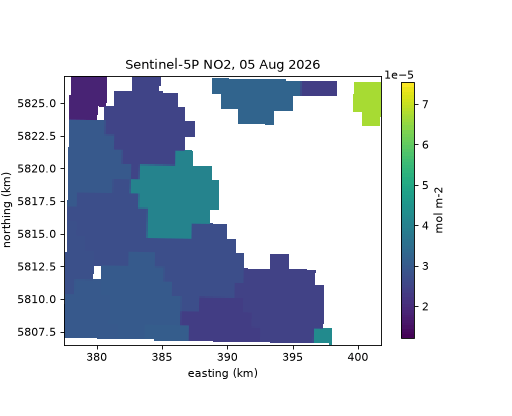

In [8]:
no2 = sentinel5p["NO2"]
no2 = no2.isel(time=np.flatnonzero(no2.notnull().mean(["y", "x"]).values >= 0.5))
no2_low, no2_high = np.nanpercentile(no2.values, [2, 98])

fig, ax = plt.subplots(figsize=(6.4, 5.2))
image = show_map(ax, no2.isel(time=0), "", cmap="viridis", label=no2.attrs.get("units", ""), vmin=no2_low, vmax=no2_high)


def update(index):
    layer = no2.isel(time=index)
    image.set_data(layer.values)
    ax.set_title(f"Sentinel-5P NO2, {pd.Timestamp(layer.time.values):%d %b %Y}")
    return (image,)


save_animation(animation.FuncAnimation(fig, update, frames=no2.sizes["time"]), "no2_berlin", fps=1)

In [9]:
pd.DataFrame([{"file": p.name, "MB": round(p.stat().st_size / 1e6, 2)} for p in sorted(ANIMATIONS.iterdir())])

,file,MB
0,lst_berlin.gif,0.36
1,lst_berlin.mp4,0.40
2,map_and_series.gif,0.53
3,map_and_series.mp4,0.47
4,no2_berlin.gif,0.05
5,no2_berlin.mp4,0.07
6,observed_vs_downscaled.gif,1.36
7,observed_vs_downscaled.mp4,2.23
8,sentinel2_timelapse.gif,0.83
9,sentinel2_timelapse.mp4,1.19


## Next

[06 Worker API](06_worker_api.ipynb) runs the same analyses as jobs over HTTP.